# Machine Learning Methods for Data Streams
## Project: Concept Drift Detection in Polarized News Streams

In [4]:
import json
import random
from collections import defaultdict
import matplotlib.pyplot as plt
from datetime import datetime
from river import compose, base, forest, metrics, drift, utils
from sentence_transformers import SentenceTransformer
from river import linear_model, optim, preprocessing
import matplotlib.pyplot as plt
from collections import deque, Counter
from datetime import datetime

### 3. Transformer based embeddings and concept drift detection

Elevating baseline by using transformer-based embeddings instead of TF-IDF and Logistir Regression instead of Naive Bayes.

In [5]:
def extract_max_one_per_class_per_day(input_data):
    grouped_data = defaultdict(lambda: {0: [], 1: []})

    for line in input_data:
        if line.strip():
            obj = json.loads(line)
            timestamp = obj["timestamp"]
            label = obj["label"]

            date_only = timestamp[:10] 
            
            extracted_obj = {
                "timestamp": timestamp,
                "label": label,
                "text": obj.get("text", "")
            }
            
            grouped_data[date_only][label].append(extracted_obj)

    selected_data = []
    
    for date, classes in grouped_data.items():
        class_0_items = classes[0]
        class_1_items = classes[1]
        
        if class_0_items:
            selected_data.append(random.choice(class_0_items))
            
        if class_1_items:
            selected_data.append(random.choice(class_1_items))

    selected_data.sort(key=lambda x: x["timestamp"])

    return selected_data


In [6]:
FILE_PATH = "data/polarized_combined1.jsonl" 
with open(FILE_PATH, 'r', encoding='utf-8') as f:
    wiersze = f.readlines()
sorted_stream = extract_max_one_per_class_per_day(wiersze)

In [7]:
class StreamSentenceTransformer(base.Transformer):
    def __init__(self, model_name='all-MiniLM-L6-v2'):
        print(f"Loading SentenceTransformer model '{model_name}'...")
        self.encoder = SentenceTransformer(model_name)
        
    def transform_one(self, x):
        vector = self.encoder.encode(x)
        return {f"emb_{i}": float(val) for i, val in enumerate(vector)}

In [8]:
def run_experiment(data_stream):
    
    model = compose.Pipeline(
        ('vectorizer', StreamSentenceTransformer('all-MiniLM-L6-v2')),
        ('scaler', preprocessing.StandardScaler()),
        ('classifier', linear_model.LogisticRegression(optimizer=optim.SGD(0.05))) 
    )
    
    metric = utils.Rolling(metrics.Accuracy(), window_size=50) 
    dates, accuracies = [], []
    
    stream_list = list(data_stream)
    latest_seen_date = datetime.fromisoformat(stream_list[0]['timestamp'].replace('Z', '+00:00'))
    
    for i, record in enumerate(stream_list):
        text = record['text']
        label = record['label'] 
        
        current_date = datetime.fromisoformat(record['timestamp'].replace('Z', '+00:00'))
        if current_date > latest_seen_date:
            latest_seen_date = current_date
            
        y_pred = model.predict_one(text)
        
        if y_pred is not None:
            metric.update(label, y_pred)
            dates.append(latest_seen_date)
            accuracies.append(metric.get())
        
        model.learn_one(text, label)
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} articles out of {len(stream_list)}.")

    return dates, accuracies

In [11]:
steps_llm_fixed, acc_llm_fixed = run_experiment(sorted_stream)

Loading SentenceTransformer model 'all-MiniLM-L6-v2'...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Processed 100 articles out of 890.
Processed 200 articles out of 890.
Processed 300 articles out of 890.
Processed 400 articles out of 890.
Processed 500 articles out of 890.
Processed 600 articles out of 890.
Processed 700 articles out of 890.
Processed 800 articles out of 890.


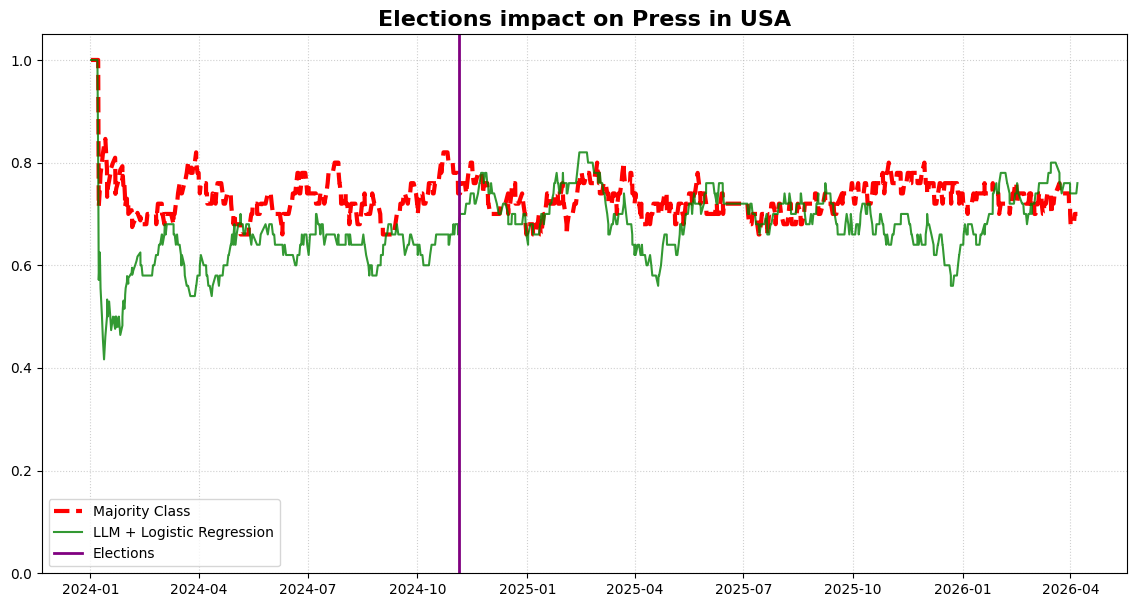

In [12]:
window_size = 50
window_labels = deque(maxlen=window_size)

dates_baseline = []
majority_acc = []

stream_list = list(sorted_stream)
latest_seen_date = datetime.fromisoformat(stream_list[0]['timestamp'].replace('Z', '+00:00'))

for record in stream_list:
    current_date = datetime.fromisoformat(record['timestamp'].replace('Z', '+00:00'))
    if current_date > latest_seen_date:
        latest_seen_date = current_date
        
    label = record['label']
    window_labels.append(label)
    
    if len(window_labels) > 0:
        most_common_count = Counter(window_labels).most_common(1)[0][1]
        acc = most_common_count / len(window_labels)
        
        dates_baseline.append(latest_seen_date)
        majority_acc.append(acc)

plt.figure(figsize=(14, 7))
plt.plot(dates_baseline, majority_acc, color='red', linewidth=3, linestyle='--', 
         label='Majority Class')
plt.plot(steps_llm_fixed, acc_llm_fixed, color='green', linewidth=1.5, alpha=0.8, label='LLM + Logistic Regression')
plt.title('Elections impact on Press in USA', fontsize=16, fontweight='bold')
plt.axvline(x=datetime.fromisoformat("2024-11-05+00:00"), color='purple', linestyle='-', linewidth=2, label='Elections')
plt.ylim(0.0, 1.05)
plt.legend(loc='lower left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()